Drive Mount

Exploratory Data Analysis and Linear Regression Modeling for Earthquake Magnitude Prediction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Data Loading and Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-ready plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('/content/drive/MyDrive/MINspire Google Colab/nepal_earthquakes_1990_2026.csv')
display(df.head())

print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Missing values: {df.isnull().sum().sum()}")

# Display basic info
print("\n" + "="*60)
print("COLUMN INFORMATION")
print("="*60)
df_info = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null%': (df.isnull().sum() / len(df) * 100).values,
    'Unique': df.nunique().values
})
print(df_info.to_string(index=False))

# Statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY (Numerical Columns)")
print("="*60)
print(df.describe())

# Check for duplicate events
duplicates = df.duplicated(subset=['time', 'latitude', 'longitude']).sum()
print(f"\nPotential duplicate events: {duplicates}")

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,magError,magNst,status,locationSource,magSource,datetime,year,month,day,hour
0,2025-12-07T02:43:07.342Z,29.8698,80.9384,43.404,4.4,mb,21.0,166.0,8.856,0.94,...,0.144,14.0,reviewed,us,us,2025-12-07 02:43:07.342000+00:00,2025,12,7,2
1,2025-12-04T11:59:01.015Z,29.1109,87.0043,10.000,4.1,mb,36.0,168.0,3.646,1.26,...,0.103,26.0,reviewed,us,us,2025-12-04 11:59:01.015000+00:00,2025,12,4,11
2,2025-11-10T22:44:15.027Z,29.1757,86.8367,10.000,4.2,mb,14.0,164.0,3.779,0.57,...,0.199,7.0,reviewed,us,us,2025-11-10 22:44:15.027000+00:00,2025,11,10,22
3,2025-11-03T20:57:22.312Z,28.5267,87.3673,10.000,4.7,mb,64.0,79.0,3.493,0.77,...,0.058,89.0,reviewed,us,us,2025-11-03 20:57:22.312000+00:00,2025,11,3,20
4,2025-10-21T14:59:40.611Z,29.0245,85.3683,10.000,4.1,mb,25.0,163.0,5.072,0.44,...,0.103,26.0,reviewed,us,us,2025-10-21 14:59:40.611000+00:00,2025,10,21,14


DATA OVERVIEW
Total records: 1,363
Date range: 1990-01-10T23:01:21.960Z to 2025-12-07T02:43:07.342Z
Memory usage: 1.05 MB
Missing values: 1846

COLUMN INFORMATION
         Column    Type  Non-Null     Null%  Unique
           time  object      1363  0.000000    1363
       latitude float64      1363  0.000000    1275
      longitude float64      1363  0.000000    1312
          depth float64      1363  0.000000     337
            mag float64      1363  0.000000      37
        magType  object      1363  0.000000       8
            nst float64      1363  0.000000     131
            gap float64      1363  0.000000     445
           dmin float64      1363  0.000000     652
            rms float64      1363  0.000000     138
            net  object      1363  0.000000       2
             id  object      1363  0.000000    1363
        updated  object      1363  0.000000    1197
          place  object      1363  0.000000    1081
           type  object      1363  0.000000       1
horiz

Data Cleaning

In [ ]:

def clean_earthquake_data(df):
    """
    Comprehensive data cleaning function
    """
    df_clean = df.copy()

    # 1. Handle missing values
    print("Handling missing values...")
    missing_before = df_clean.isnull().sum().sum()

    # Drop rows where critical columns are missing
    critical_cols = ['time', 'latitude', 'longitude', 'mag']
    df_clean = df_clean.dropna(subset=critical_cols)

    # Fill other missing values with column means
    for col in ['depth', 'nst', 'gap', 'dmin', 'rms']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    missing_after = df_clean.isnull().sum().sum()
    print(f"  Missing values: {missing_before} → {missing_after}")

    # 2. Remove outliers based on domain knowledge
    print("Removing outliers...")
    before_count = len(df_clean)

    # Earthquakes should have reasonable magnitudes (3.0-9.0)
    df_clean = df_clean[(df_clean['mag'] >= 3.0) & (df_clean['mag'] <= 9.0)]

    # Depth should be reasonable (0-700km)
    df_clean = df_clean[(df_clean['depth'] >= 0) & (df_clean['depth'] <= 700)]

    # Lat/Lon should be valid (Nepal region: 26-31°N, 80-88°E)
    df_clean = df_clean[(df_clean['latitude'] >= 26) & (df_clean['latitude'] <= 31)]
    df_clean = df_clean[(df_clean['longitude'] >= 80) & (df_clean['longitude'] <= 88)]

    after_count = len(df_clean)
    print(f"  Removed {before_count - after_count} outliers ({100*(before_count-after_count)/before_count:.1f}%)")

    # 3. Convert time to datetime
    df_clean['datetime'] = pd.to_datetime(df_clean['time'])
    df_clean['year'] = df_clean['datetime'].dt.year
    df_clean['month'] = df_clean['datetime'].dt.month
    df_clean['day'] = df_clean['datetime'].dt.day
    df_clean['hour'] = df_clean['datetime'].dt.hour

    # 4. Remove unrealistic depth values (negative or zero)
    df_clean = df_clean[df_clean['depth'] > 0]

    # 5. Cap extreme values
    for col in ['nst', 'gap']:
        if col in df_clean.columns:
            upper = df_clean[col].quantile(0.99)
            df_clean[col] = df_clean[col].clip(upper=upper)

    print(f"\nFinal dataset size: {len(df_clean)} events")

    return df_clean

# Apply cleaning
df_clean = clean_earthquake_data(df)
df_clean.to_csv('/content/drive/MyDrive/MINspire Google Colab/nepal_earthquakes_1990_2026.csv', index=False)
print("\n Cleaned data saved to '../data/nepal_earthquakes_cleaned.csv'")
display(df.head())

Handling missing values...
  Missing values: 1846 → 1846
Removing outliers...
  Removed 0 outliers (0.0%)

Final dataset size: 1363 events

 Cleaned data saved to '../data/nepal_earthquakes_cleaned.csv'


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,magError,magNst,status,locationSource,magSource,datetime,year,month,day,hour
0,2025-12-07T02:43:07.342Z,29.8698,80.9384,43.404,4.4,mb,21.0,166.0,8.856,0.94,...,0.144,14.0,reviewed,us,us,2025-12-07 02:43:07.342000+00:00,2025,12,7,2
1,2025-12-04T11:59:01.015Z,29.1109,87.0043,10.000,4.1,mb,36.0,168.0,3.646,1.26,...,0.103,26.0,reviewed,us,us,2025-12-04 11:59:01.015000+00:00,2025,12,4,11
2,2025-11-10T22:44:15.027Z,29.1757,86.8367,10.000,4.2,mb,14.0,164.0,3.779,0.57,...,0.199,7.0,reviewed,us,us,2025-11-10 22:44:15.027000+00:00,2025,11,10,22
3,2025-11-03T20:57:22.312Z,28.5267,87.3673,10.000,4.7,mb,64.0,79.0,3.493,0.77,...,0.058,89.0,reviewed,us,us,2025-11-03 20:57:22.312000+00:00,2025,11,3,20
4,2025-10-21T14:59:40.611Z,29.0245,85.3683,10.000,4.1,mb,25.0,163.0,5.072,0.44,...,0.103,26.0,reviewed,us,us,2025-10-21 14:59:40.611000+00:00,2025,10,21,14


Data Visualization

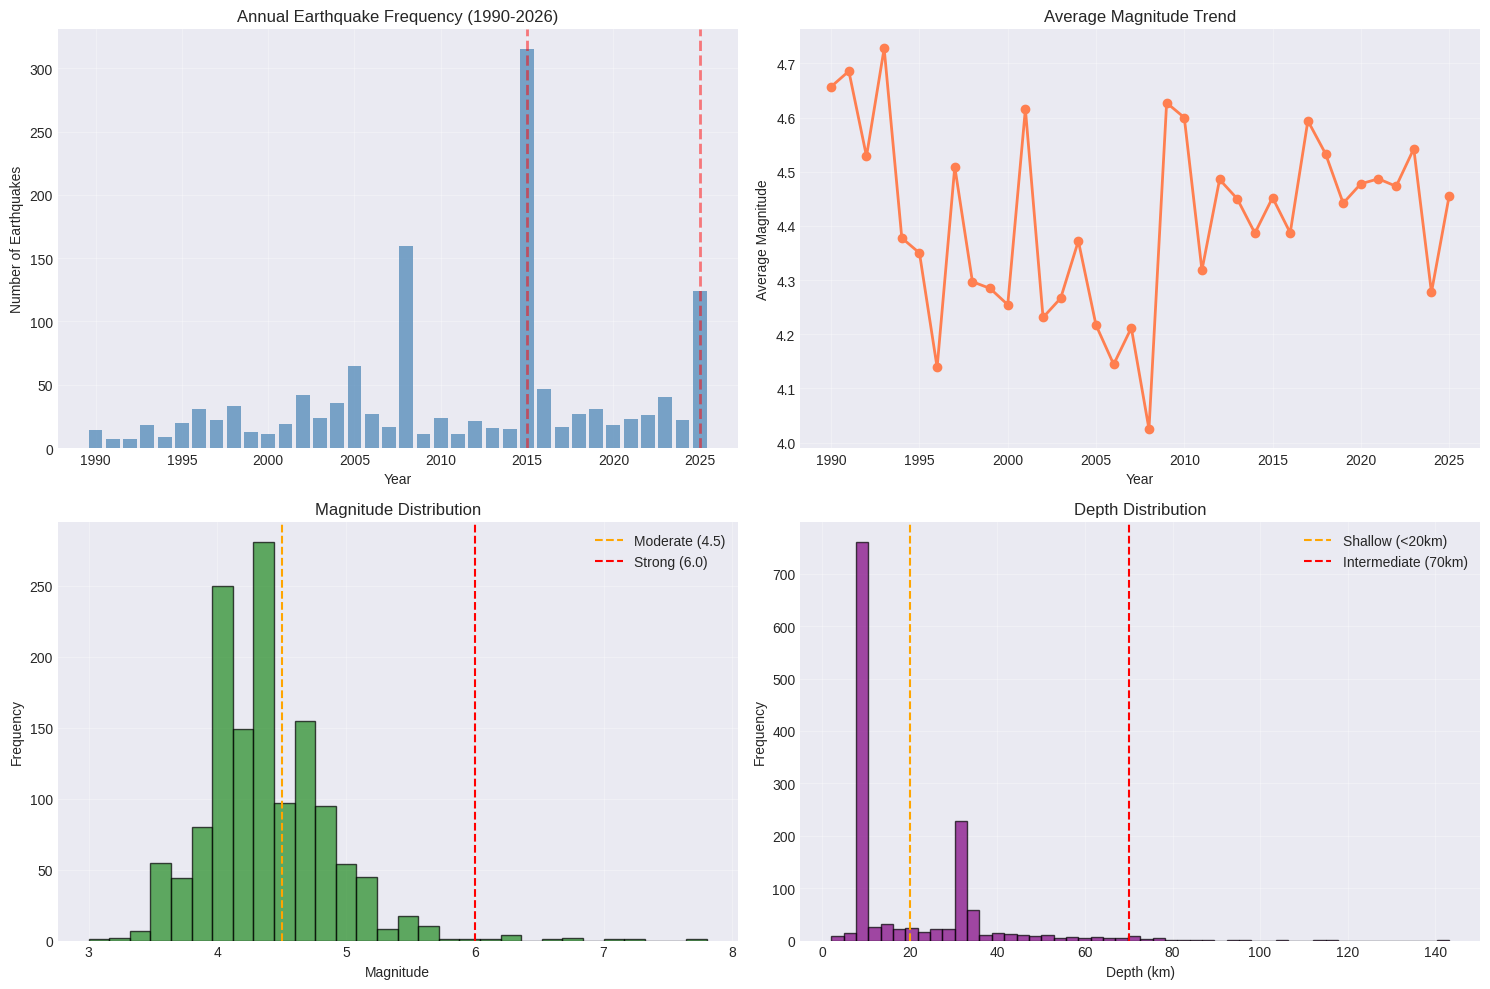

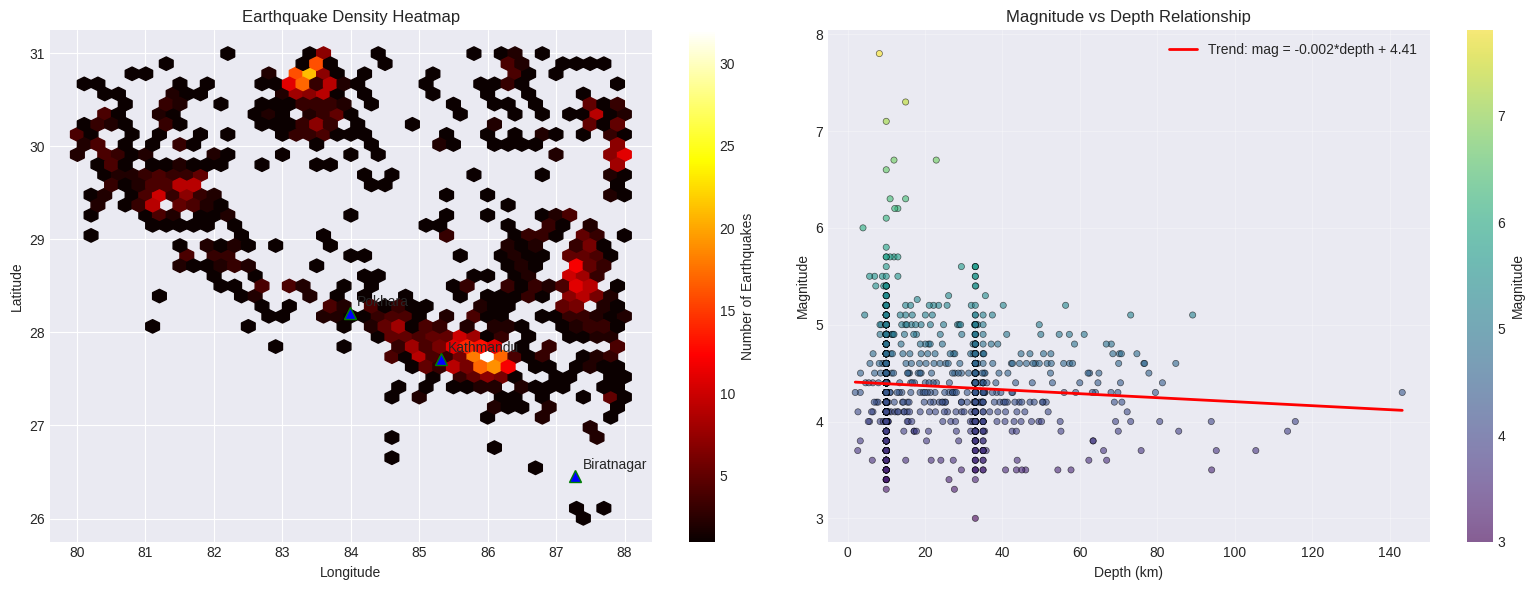

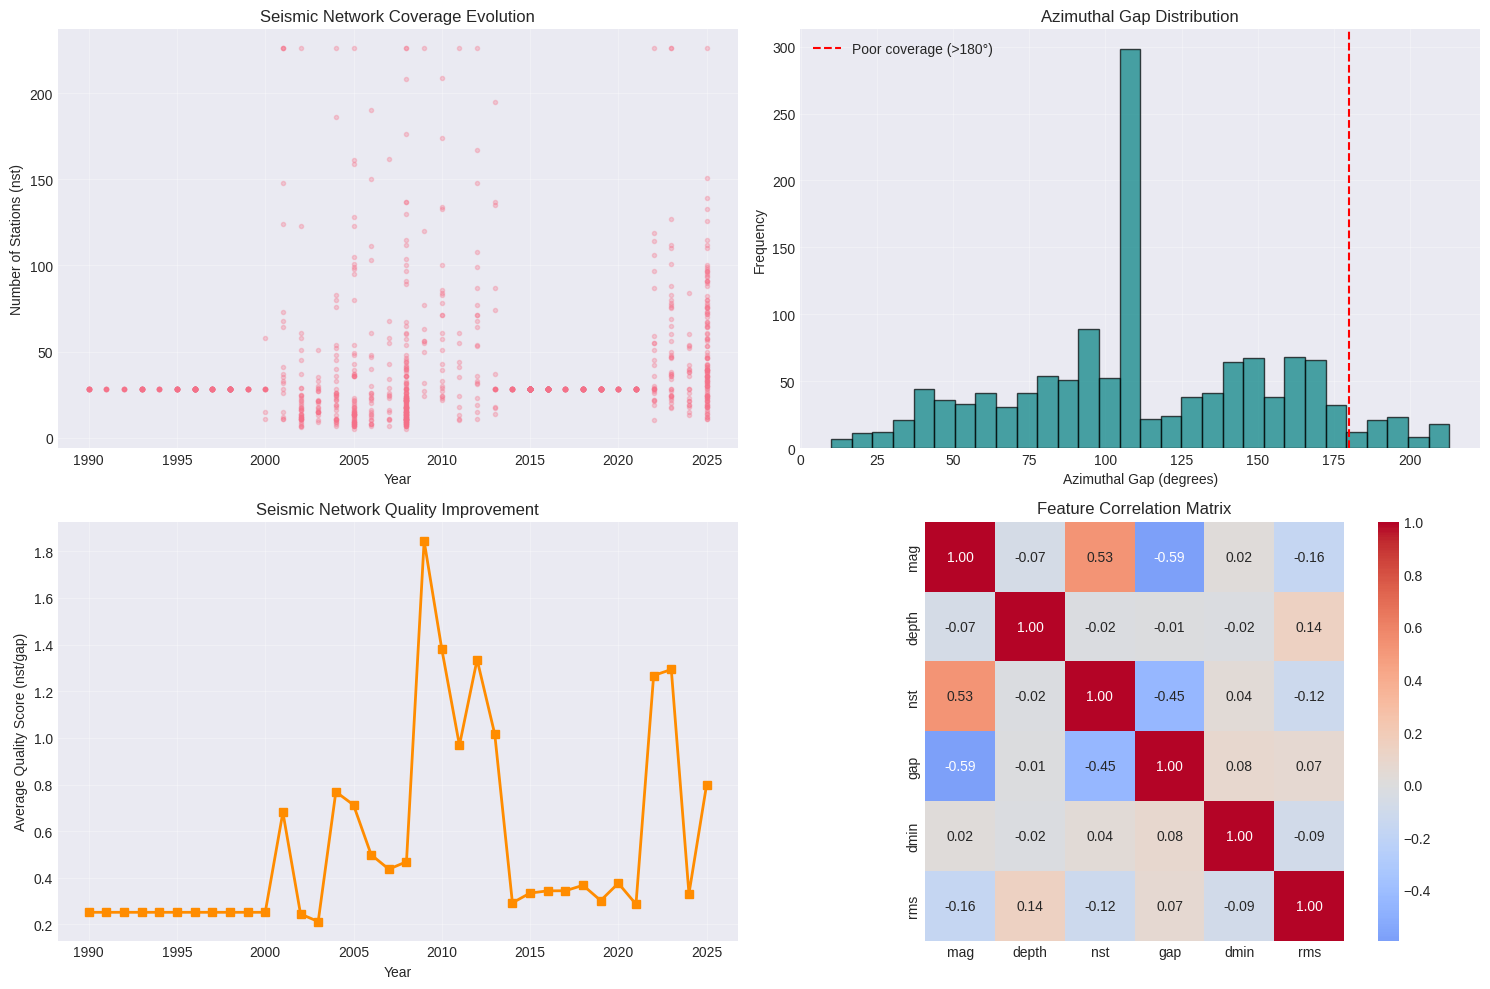


EDA SUMMARY REPORT

 Basic Statistics:
  • Total earthquakes: 1,363
  • Magnitude range: 3.0 - 7.8
  • Average magnitude: 4.37 ± 0.48
  • Average depth: 20.4 ± 16.2 km

 Major Events (M ≥ 6.0):
  • 2015-04-25: M7.8 at (28.23, 84.73)
  • 2015-05-12: M7.3 at (27.81, 86.07)
  • 2025-01-07: M7.1 at (28.60, 87.38)
  • 2015-04-26: M6.7 at (27.77, 86.02)
  • 2008-08-25: M6.7 at (30.90, 83.52)

 Temporal Trends:
  • Most active year: 2015 (315 events)
  • Least active year: 1991 (7 events)

🔍 Network Quality:
  • Average stations per event: 36
  • Average azimuthal gap: 113°
  • Improved coverage: 36 vs 37 (pre-2015)


In [ ]:

class EarthquakeEDA:
    def __init__(self, df):
        self.df = df

    def plot_temporal_distribution(self):
        """Time series analysis of earthquake frequency"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 1. Earthquakes per year
        yearly_counts = self.df.groupby('year').size()
        yearly_mag = self.df.groupby('year')['mag'].mean()

        ax1 = axes[0, 0]
        ax1.bar(yearly_counts.index, yearly_counts.values, alpha=0.7, color='steelblue')
        ax1.set_xlabel('Year')
        ax1.set_ylabel('Number of Earthquakes')
        ax1.set_title('Annual Earthquake Frequency (1990-2026)')
        ax1.grid(True, alpha=0.3)

        # Highlight major events
        major_years = [2015, 2025]  # Gorkha earthquake and 2025 event
        for year in major_years:
            ax1.axvline(x=year, color='red', linestyle='--', alpha=0.5, linewidth=2)

        # 2. Average magnitude per year
        ax2 = axes[0, 1]
        ax2.plot(yearly_mag.index, yearly_mag.values, marker='o', linewidth=2, color='coral')
        ax2.set_xlabel('Year')
        ax2.set_ylabel('Average Magnitude')
        ax2.set_title('Average Magnitude Trend')
        ax2.grid(True, alpha=0.3)

        # 3. Magnitude distribution
        ax3 = axes[1, 0]
        ax3.hist(self.df['mag'], bins=30, alpha=0.7, color='forestgreen', edgecolor='black')
        ax3.set_xlabel('Magnitude')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Magnitude Distribution')
        ax3.axvline(x=4.5, color='orange', linestyle='--', label='Moderate (4.5)')
        ax3.axvline(x=6.0, color='red', linestyle='--', label='Strong (6.0)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. Depth distribution
        ax4 = axes[1, 1]
        ax4.hist(self.df['depth'], bins=50, alpha=0.7, color='purple', edgecolor='black')
        ax4.set_xlabel('Depth (km)')
        ax4.set_ylabel('Frequency')
        ax4.set_title('Depth Distribution')
        ax4.axvline(x=20, color='orange', linestyle='--', label='Shallow (<20km)')
        ax4.axvline(x=70, color='red', linestyle='--', label='Intermediate (70km)')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        #plt.savefig('../visualizations/temporal_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

    def plot_spatial_distribution(self):
        """Geospatial analysis of earthquakes"""
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # 1. 2D Density Plot (Heatmap)
        ax1 = axes[0]
        hb = ax1.hexbin(self.df['longitude'], self.df['latitude'],
                        gridsize=40, cmap='hot', mincnt=1)
        ax1.set_xlabel('Longitude')
        ax1.set_ylabel('Latitude')
        ax1.set_title('Earthquake Density Heatmap')
        plt.colorbar(hb, ax=ax1, label='Number of Earthquakes')



        # Add major cities for reference
        cities = {'Kathmandu': (85.3240, 27.7172),
                  'Pokhara': (83.9858, 28.2096),
                  'Biratnagar': (87.2830, 26.4525)}
        for city, (lon, lat) in cities.items():
            ax1.plot(lon, lat, 'b^', markersize=8, markeredgecolor='green')
            ax1.annotate(city, (lon, lat), xytext=(5, 5), textcoords='offset points')

        # 2. Magnitude vs Depth scatter
        ax2 = axes[1]
        scatter = ax2.scatter(self.df['depth'], self.df['mag'],
                             c=self.df['mag'], cmap='viridis',
                             alpha=0.6, s=20, edgecolors='black', linewidth=0.5)
        ax2.set_xlabel('Depth (km)')
        ax2.set_ylabel('Magnitude')
        ax2.set_title('Magnitude vs Depth Relationship')
        ax2.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax2, label='Magnitude')

        # Add trend line
        z = np.polyfit(self.df['depth'], self.df['mag'], 1)
        p = np.poly1d(z)
        ax2.plot(self.df['depth'].sort_values(),
                p(self.df['depth'].sort_values()),
                'r-', linewidth=2, label=f'Trend: mag = {z[0]:.3f}*depth + {z[1]:.2f}')
        ax2.legend()

        plt.tight_layout()
       # plt.savefig('../visualizations/spatial_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

    def plot_seismic_network_quality(self):
        """Analyze the quality of seismic recordings"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 1. Number of stations (nst) over time
        ax1 = axes[0, 0]
        ax1.plot(self.df['year'], self.df['nst'], 'o', alpha=0.3, markersize=3)
        ax1.set_xlabel('Year')
        ax1.set_ylabel('Number of Stations (nst)')
        ax1.set_title('Seismic Network Coverage Evolution')
        ax1.grid(True, alpha=0.3)

        # 2. Azimuthal gap distribution
        ax2 = axes[0, 1]
        ax2.hist(self.df['gap'], bins=30, alpha=0.7, color='teal', edgecolor='black')
        ax2.set_xlabel('Azimuthal Gap (degrees)')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Azimuthal Gap Distribution')
        ax2.axvline(x=180, color='red', linestyle='--', label='Poor coverage (>180°)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Network quality score over time
        ax3 = axes[1, 0]
        df_quality = self.df.copy()
        df_quality['quality_score'] = df_quality['nst'] / (df_quality['gap'] + 1)
        yearly_quality = df_quality.groupby('year')['quality_score'].mean()
        ax3.plot(yearly_quality.index, yearly_quality.values, marker='s', linewidth=2, color='darkorange')
        ax3.set_xlabel('Year')
        ax3.set_ylabel('Average Quality Score (nst/gap)')
        ax3.set_title('Seismic Network Quality Improvement')
        ax3.grid(True, alpha=0.3)

        # 4. Correlation heatmap
        ax4 = axes[1, 1]
        corr_cols = ['mag', 'depth', 'nst', 'gap', 'dmin', 'rms']
        corr_matrix = self.df[corr_cols].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, ax=ax4, fmt='.2f')
        ax4.set_title('Feature Correlation Matrix')

        plt.tight_layout()
        #plt.savefig('../visualizations/network_quality.png', dpi=150, bbox_inches='tight')
        plt.show()

    def generate_eda_report(self):
        """Generate comprehensive EDA summary"""
        print("\n" + "="*60)
        print("EDA SUMMARY REPORT")
        print("="*60)

        print(f"\n Basic Statistics:")
        print(f"  • Total earthquakes: {len(self.df):,}")
        print(f"  • Magnitude range: {self.df['mag'].min():.1f} - {self.df['mag'].max():.1f}")
        print(f"  • Average magnitude: {self.df['mag'].mean():.2f} ± {self.df['mag'].std():.2f}")
        print(f"  • Average depth: {self.df['depth'].mean():.1f} ± {self.df['depth'].std():.1f} km")

        print(f"\n Major Events (M ≥ 6.0):")
        major_events = self.df[self.df['mag'] >= 6.0].sort_values('mag', ascending=False)
        for _, event in major_events.head(5).iterrows():
            print(f"  • {event['datetime'].strftime('%Y-%m-%d')}: M{event['mag']:.1f} at "
                  f"({event['latitude']:.2f}, {event['longitude']:.2f})")

        print(f"\n Temporal Trends:")
        yearly_counts = self.df.groupby('year').size()
        print(f"  • Most active year: {yearly_counts.idxmax()} ({yearly_counts.max()} events)")
        print(f"  • Least active year: {yearly_counts.idxmin()} ({yearly_counts.min()} events)")

        print(f"\n🔍 Network Quality:")
        print(f"  • Average stations per event: {self.df['nst'].mean():.0f}")
        print(f"  • Average azimuthal gap: {self.df['gap'].mean():.0f}°")
        print(f"  • Improved coverage: {self.df[self.df['year']>=2015]['nst'].mean():.0f} "
              f"vs {self.df[self.df['year']<2015]['nst'].mean():.0f} (pre-2015)")

# Run EDA
eda = EarthquakeEDA(df_clean)
eda.plot_temporal_distribution()
eda.plot_spatial_distribution()
eda.plot_seismic_network_quality()
eda.generate_eda_report()

Feature Engineering

In [ ]:

class FeatureEngineer:
    def __init__(self, df):
        self.df = df

    def create_seismic_features(self):
        """Create domain-specific features"""
        df_feat = self.df.copy()

        # 1. Depth-based categories
        df_feat['depth_category'] = pd.cut(df_feat['depth'],
                                            bins=[0, 20, 70, 700],
                                            labels=['Shallow', 'Intermediate', 'Deep'])

        # 2. Network quality metrics
        df_feat['network_quality'] = df_feat['nst'] / (df_feat['gap'] + 1)
        df_feat['coverage_score'] = (df_feat['nst'] / df_feat['nst'].max()) * (1 - df_feat['gap']/360)
        df_feat['data_reliability'] = 1 / (df_feat['rms'] + 0.01)

        # 3. Distance-based features
        df_feat['mag_distance_ratio'] = df_feat['mag'] / (df_feat['dmin'] + 10)
        df_feat['normalized_distance'] = (df_feat['dmin'] - df_feat['dmin'].min()) / (df_feat['dmin'].max() - df_feat['dmin'].min())

        # 4. Temporal features (cyclic encoding)
        df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
        df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
        df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
        df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)

        # 5. Aftershock detection
        # Sort by time
        df_feat = df_feat.sort_values('datetime')

        # Identify major events (M > 6)
        major_events = df_feat[df_feat['mag'] > 6].copy()

        df_feat['is_aftershock'] = 0
        for idx, major in major_events.iterrows():
            # Events within 90 days and 100km of major event
            mask = (abs(df_feat['datetime'] - major['datetime']).dt.days <= 90) & \
                   (abs(df_feat['latitude'] - major['latitude']) <= 1) & \
                   (abs(df_feat['longitude'] - major['longitude']) <= 1)
            df_feat.loc[mask, 'is_aftershock'] = 1

        # 6. Spatial clustering (simplified)
        from sklearn.cluster import KMeans
        coords = df_feat[['latitude', 'longitude']].values
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        df_feat['spatial_cluster'] = kmeans.fit_predict(coords)

        # 7. Magnitude squared (for non-linear relationships)
        df_feat['mag_squared'] = df_feat['mag'] ** 2

        # 8. Interaction features
        df_feat['depth_mag_interaction'] = df_feat['depth'] * df_feat['mag']
        df_feat['nst_gap_ratio'] = df_feat['nst'] / (df_feat['gap'] + 1)

        print(f" Created {len(df_feat.columns) - len(self.df.columns)} new features")
        print(f"Final feature set: {list(df_feat.columns)}")

        return df_feat

    def select_features_for_modeling(self, df_feat):
        """Select optimal features for ML models"""

        # Define feature groups
        basic_features = ['depth', 'nst', 'gap', 'dmin', 'rms']
        engineered_features = ['network_quality', 'mag_distance_ratio', 'data_reliability',
                               'coverage_score', 'nst_gap_ratio']
        temporal_features = ['month_sin', 'month_cos', 'hour_sin', 'hour_cos']
        categorical_features = ['is_aftershock', 'spatial_cluster']

        # Combine all features
        all_features = basic_features + engineered_features + temporal_features + categorical_features
        target = 'mag'

        # Ensure all features exist
        available_features = [f for f in all_features if f in df_feat.columns]

        print(f"\n Selected Features ({len(available_features)}):")
        for i, feature in enumerate(available_features):
            print(f"  {i+1:2d}. {feature}")

        return available_features, target

# Apply feature engineering
engineer = FeatureEngineer(df_clean)
df_features = engineer.create_seismic_features()
features, target = engineer.select_features_for_modeling(df_features)

# Save processed data
df_features[features + [target]].to_csv('/content/drive/MyDrive/features_processed.csv', index=False)
print("\n Feature-engineered data saved to '../data/features_processed.csv'")

 Created 15 new features
Final feature set: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource', 'datetime', 'year', 'month', 'day', 'hour', 'depth_category', 'network_quality', 'coverage_score', 'data_reliability', 'mag_distance_ratio', 'normalized_distance', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_aftershock', 'spatial_cluster', 'mag_squared', 'depth_mag_interaction', 'nst_gap_ratio']

 Selected Features (16):
   1. depth
   2. nst
   3. gap
   4. dmin
   5. rms
   6. network_quality
   7. mag_distance_ratio
   8. data_reliability
   9. coverage_score
  10. nst_gap_ratio
  11. month_sin
  12. month_cos
  13. hour_sin
  14. hour_cos
  15. is_aftershock
  16. spatial_cluster

 Feature-engineered data saved to '../data/features_processed.csv'


Linear Regression Modelling
Data Preparation for Modelling

In [ ]:

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load feature data
df_model = pd.read_csv('/content/drive/MyDrive/features_processed.csv')

# Separate features and target
X = df_model[features].copy()
y = df_model[target].copy()

# Handle categorical features
categorical_features = ['spatial_cluster']  # is_aftershock is binary
numeric_features = [f for f in features if f not in categorical_features]

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Features: {len(numeric_features)} numeric + {len(categorical_features)} categorical")

Training set: 1090 samples
Test set: 273 samples
Features: 15 numeric + 1 categorical


Train Multipke Linear Regression Variants

In [ ]:
class LinearRegressionModels:
    def __init__(self, X_train, X_test, y_train, y_test, preprocessor):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.preprocessor = preprocessor
        self.models = {}
        self.results = {}

    def train_all_models(self):
        """Train multiple linear regression variants"""

        # 1. Standard Linear Regression
        print("Training Standard Linear Regression...")
        lr_pipeline = Pipeline([
            ('preprocessor', self.preprocessor),
            ('regressor', LinearRegression())
        ])
        lr_pipeline.fit(self.X_train, self.y_train)
        self.models['Linear Regression'] = lr_pipeline

        # 2. Ridge Regression (L2 regularization)
        print("Training Ridge Regression...")
        ridge_pipeline = Pipeline([
            ('preprocessor', self.preprocessor),
            ('regressor', Ridge(alpha=1.0))
        ])
        ridge_pipeline.fit(self.X_train, self.y_train)
        self.models['Ridge'] = ridge_pipeline

        # 3. Lasso Regression (L1 regularization - feature selection)
        print("Training Lasso Regression...")
        lasso_pipeline = Pipeline([
            ('preprocessor', self.preprocessor),
            ('regressor', Lasso(alpha=0.01))
        ])
        lasso_pipeline.fit(self.X_train, self.y_train)
        self.models['Lasso'] = lasso_pipeline

        return self.models

    def evaluate_models(self):
        """Evaluate all trained models"""

        for name, model in self.models.items():
            # Predictions
            y_pred = model.predict(self.X_test)

            # Metrics
            mse = mean_squared_error(self.y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(self.y_test, y_pred)
            r2 = r2_score(self.y_test, y_pred)

            # Cross-validation score
            cv_scores = cross_val_score(model,
                                       pd.concat([self.X_train, self.X_test]),
                                       pd.concat([self.y_train, self.y_test]),
                                       cv=5, scoring='r2')

            self.results[name] = {
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2,
                'CV_R²_mean': cv_scores.mean(),
                'CV_R²_std': cv_scores.std()
            }

            print(f"\n{'='*40}")
            print(f"{name} RESULTS")
            print(f"{'='*40}")
            print(f"RMSE: {rmse:.4f}")
            print(f"MAE:  {mae:.4f}")
            print(f"R²:   {r2:.4f}")
            print(f"CV R²: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")

        return self.results

    def get_feature_importance(self):
        """Extract feature importance from linear models"""
        importance_dict = {}

        for name, model in self.models.items():
            if name == 'Lasso':  # Only get feature importance for Lasso
                # Get feature names after preprocessing
                preprocessor = model.named_steps['preprocessor']
                preprocessor.fit(self.X_train)

                # Get feature names
                cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out()
                all_features = list(numeric_features) + list(cat_features)

                # Get coefficients
                coefficients = model.named_steps['regressor'].coef_

                # Create importance DataFrame
                importance_df = pd.DataFrame({
                    'Feature': all_features,
                    'Coefficient': coefficients
                })
                importance_df['Abs_Coefficient'] = abs(importance_df['Coefficient'])
                importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

                importance_dict[name] = importance_df

                print(f"\n{'='*40}")
                print(f"TOP 10 FEATURES - {name}")
                print(f"{'='*40}")
                print(importance_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))

        return importance_dict

# Train and evaluate
lr_models = LinearRegressionModels(X_train, X_test, y_train, y_test, preprocessor)
lr_models.train_all_models()
results = lr_models.evaluate_models()
feature_importance = lr_models.get_feature_importance()

Training Standard Linear Regression...
Training Ridge Regression...
Training Lasso Regression...

Linear Regression RESULTS
RMSE: 0.0831
MAE:  0.0623
R²:   0.9748
CV R²: 0.9397 ± 0.0522

Ridge RESULTS
RMSE: 0.0837
MAE:  0.0628
R²:   0.9744
CV R²: 0.9398 ± 0.0516

Lasso RESULTS
RMSE: 0.0985
MAE:  0.0744
R²:   0.9646
CV R²: 0.9353 ± 0.0425

TOP 10 FEATURES - Lasso
           Feature  Coefficient
mag_distance_ratio     0.534088
              dmin     0.347991
               nst     0.035201
               gap    -0.026635
 spatial_cluster_3    -0.025702
         month_cos     0.013080
             depth     0.000000
  data_reliability    -0.000000
    coverage_score     0.000000
               rms    -0.000000


### Actual vs. Predicted Magnitude Scatter Plots

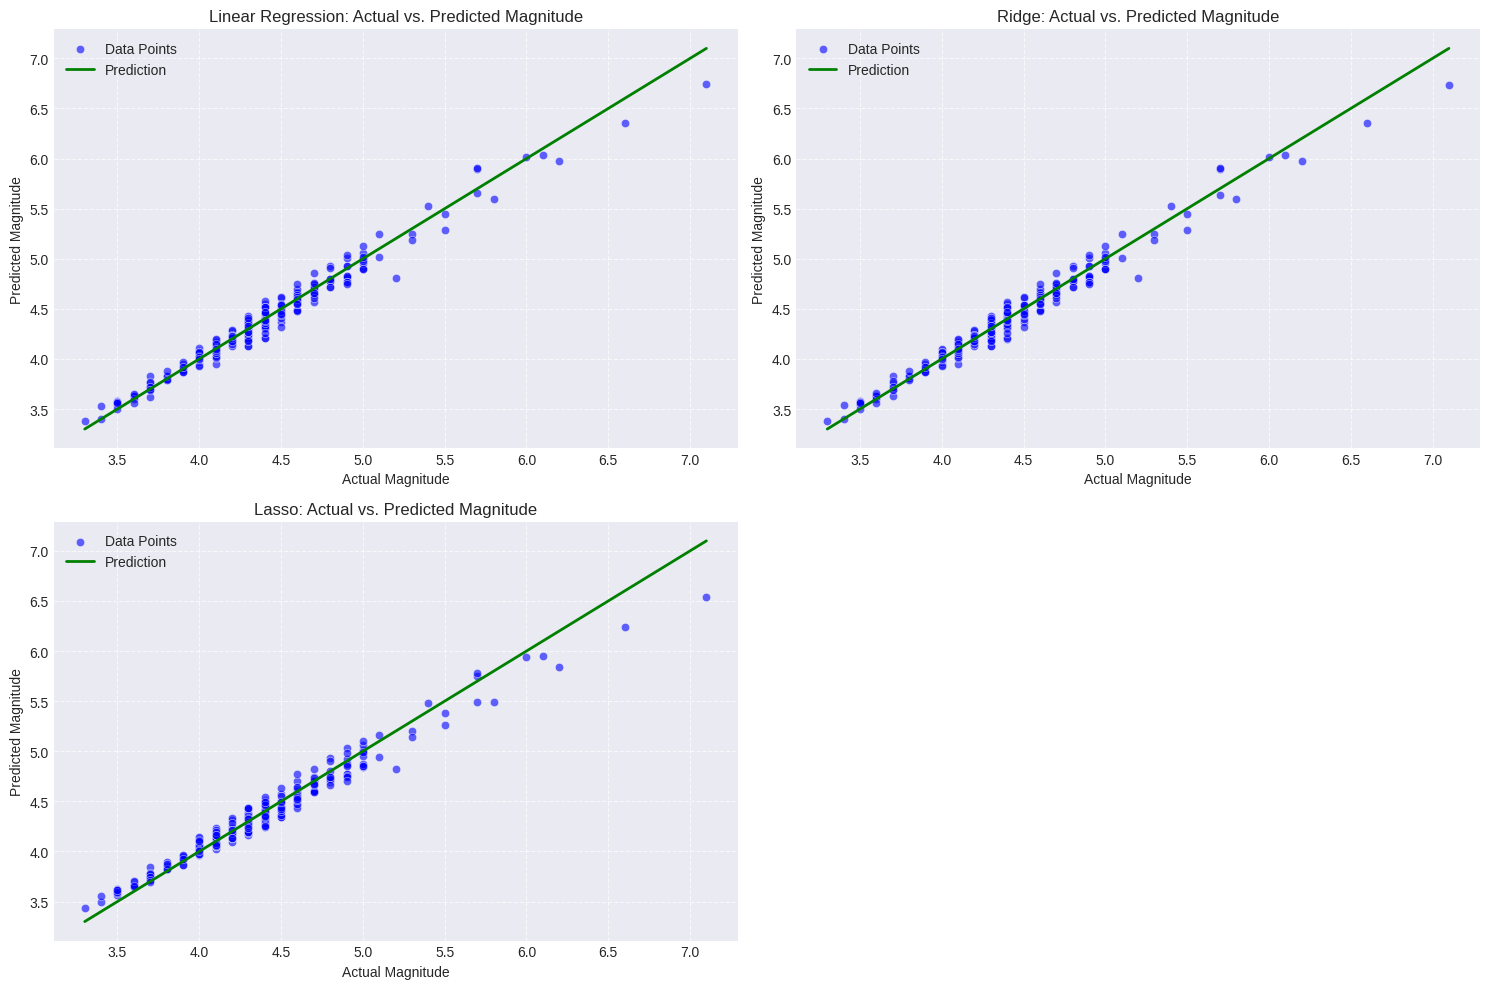

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

i = 0
for name, model in lr_models.models.items():
    if name == 'Ridge (Tuned)':
        continue
    plt.subplot(2, 2, i + 1)
    y_pred = model.predict(X_test)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, label='Data Points', color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g-', lw=2, label='Prediction')
    plt.title(f'{name}: Actual vs. Predicted Magnitude')
    plt.xlabel('Actual Magnitude')
    plt.ylabel('Predicted Magnitude')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    i += 1

plt.tight_layout()
plt.show()